機械学習→ 特徴量 や 説明変数 と呼ばれます。機械学習のモデルにデータを入力する際は、「どの特徴量を選択するか」を見極める必要がある。モデルに必要となる説明変数を選択し、与える必要がある。不要な説明変数はモデルの性能を悪化させる可能性があるため、選択は慎重に行なう必要がある

深層学習（ディープラーニング）→多層のニューラルネットワークを組み合わせて作成される機械学習モデルのこと。ディープラーニングの強みは「特徴量を自動的に抽出できる」という点。

本レッスンの実習では、 TensorFlow（テンソルフロー）と Keras（ケラス）というパッケージライブラリを使います。

深層学習では、多数の層を組み合わせてモデルを作成します。深層学習のプログラムを作る場合、TensorFlowで用意されている数多くの層に関する知識を得て、自身の手で層を組み合わせてプログラムを作る必要があり、手軽に深層学習を体験できません。そこで、転移学習 の技術を利用
転移学習は、汎用的な画像で学習済みのモデルに、分類したい種類の画像を追加で学習させることで、新しいモデルを作成する方法

In [1]:
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory( #image_dataset_from_directory() が自動で224px にリサイズして読み込み
    "nagaoka_gis/train",
    image_size=(224, 224), 
    label_mode="binary", #label_modeには、今回どのような分類を行なうかを指定,ルフ場が写っているかの有無を判定する分類のため、2値分類（binary）
    batch_size=32, #batch_sizeは、1回の学習で何枚の画像を使うかを指定
    shuffle=True #shuffleは、画像を読み込む順番をランダムにするかどうかを指定
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 20 files belonging to 2 classes.
Found 6 files belonging to 2 classes.


MobileNetV2 モデルでは、扱える画像ファイルの縦横のサイズが決まっていて、以下のいずれかの長さで縦横同じ（正方形の画像）にする必要があります


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

2025-10-15 14:49:06.589140: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[[ 81.11735 , 111.11735 ,  73.11735 ],
          [ 73.10204 , 103.10204 ,  65.10204 ],
          [ 80.53826 , 111.53826 ,  77.53826 ],
          ...,
          [ 74.94667 , 110.10738 ,  78.82167 ],
          [ 70.54414 , 103.40132 ,  76.85274 ],
          [ 61.607235,  94.60724 ,  64.97965 ]],
 
         [[ 84.22449 , 114.22449 ,  76.22449 ],
          [ 73.997444, 103.997444,  65.997444],
          [ 73.61989 , 103.61989 ,  67.61989 ],
          ...,
          [ 77.71436 , 111.75008 ,  78.01794 ],
          [ 72.59166 , 106.03555 ,  74.57113 ],
          [ 84.278046, 118.1403  ,  84.675995]],
 
         [[ 75.46938 , 105.46938 ,  67.46938 ],
          [ 78.32143 , 108.32143 ,  70.32143 ],
          [ 79.11735 , 107.11735 ,  69.11735 ],
          ...,
          [ 82.433846, 114.04099 ,  78.808846],
          [ 90.0927  , 124.0927  ,  89.04159 ],
          [ 75.53843 , 110.25272 ,  71.56901 ]],
 
         ...,
 
         [[ 50.571426,  76.24996 ,  50.268047],
          [ 83.627

In [3]:
#0と1が何を指しているかは、以下のように class_names 属性を確認
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names #no が0、yes は1
class_names

['no', 'yes']

2025-10-15 14:49:17.416258: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


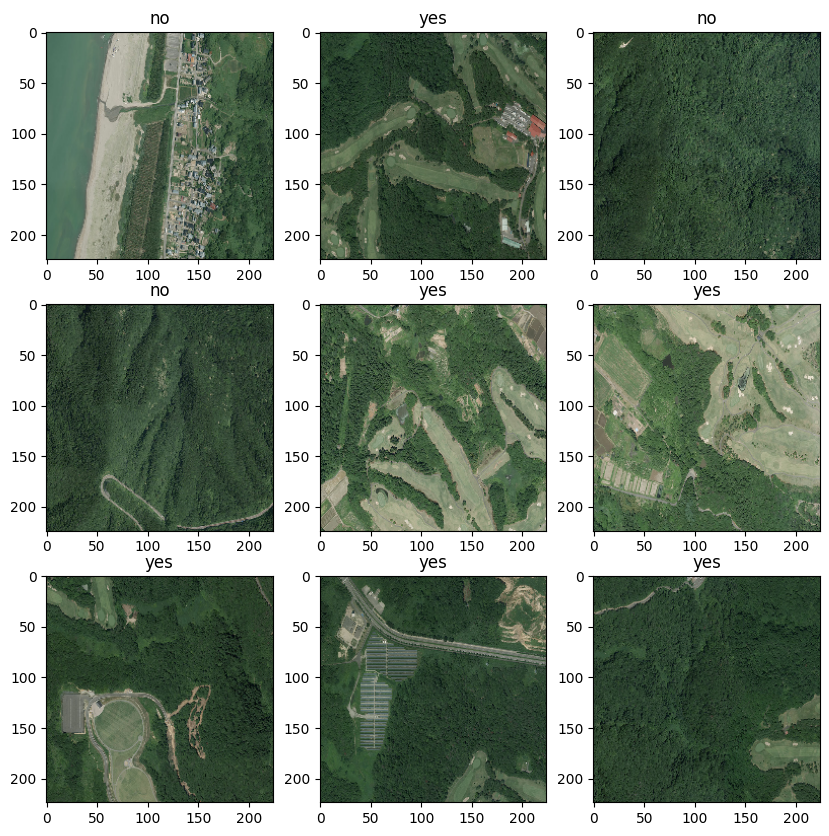

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

データの水増しを行なう
TensorFlowの機能を使って、データの水増しを行ないます
tf.image が持つメソッドを利用することで実現します。まずは、それぞれの水増しを行なうための関数を定義します。rot90() の k は、90度回転する回数の指定で、デフォルトは1回です。k=2 で180度、k=3 で270度回転


In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

train_dataset が持つ map() メソッドを使うことで、データセット内にあるすべての画像に対して、水増しが行なわれます。map() メソッドの引数には、適用する関数名を指定します。また、map() は非破壊的メソッドのため、新しい変数を用意して、出力結果を格納

In [6]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

水増し処理で作成したデータセットを、元のデータセット（train_dataset）に追加します。train_dataset が持つ concatenate() メソッドを使うことで、データセットを結合できます。concatenate() メソッドの引数には、結合したいデータセットを指定

In [7]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

train_dataset が持つ shuffle() メソッドを実行し、データセット内の画像の順番をランダムに並べ替えます。shuffle() メソッドの引数には、基本的に image_dataset_from_directory() の batch_size 引数で指定した値と同じものを指定

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

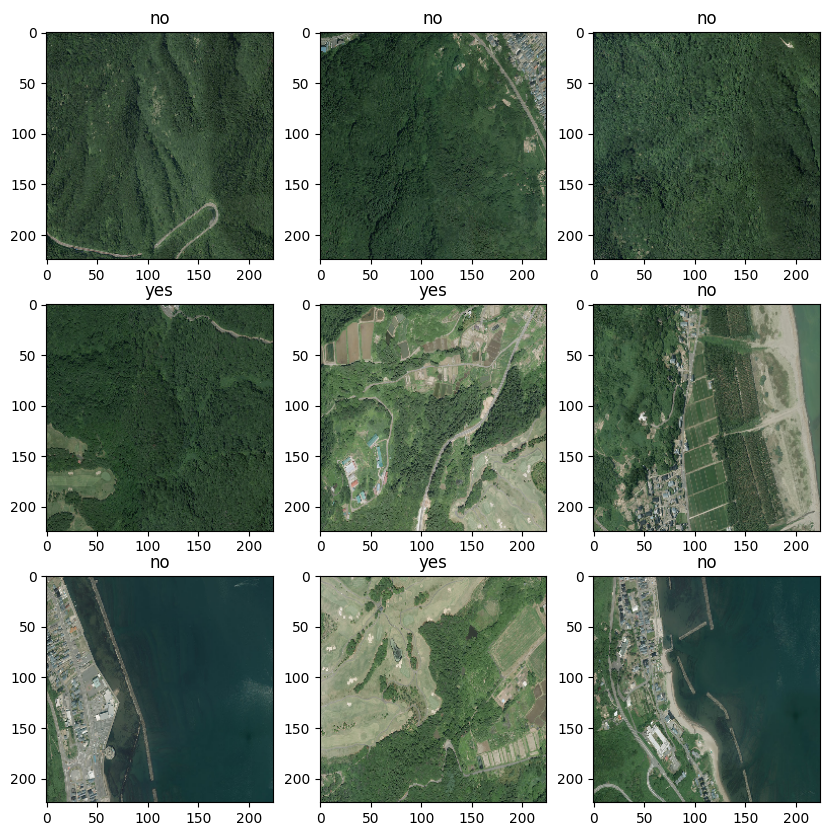

In [9]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

MobileNetV2 の学習済みモデルを読み込んで、今回の訓練データを転移学習で学習させます


In [10]:
# # MobileNetV2モデルを作成する
# input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層の作成には tf.keras.Input(),shape=(224, 224, 3) のキーワード引数には、画像のサイズと色の情報を指定,224px x 224px のカラー画像（RGB）を扱うため、shape=(224, 224, 3)
# l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層,引数には入力層を指定します。これで、入力層と正規化する層が結合,
#                                                                            #画像データ（色の強さの情報）は0から255までの数値で表されているため、入力層からのデータを正規化
# base_model = tf.keras.applications.mobilenet_v2.MobileNetV2( #MobileNetV2 のモデルはtf.keras.applications.mobilenet_v2.MobileNetV2() で読み込み
#     input_shape=(224, 224, 3), #tf.keras.Input() で shape=(224, 224, 3) としているため、同じサイズ（224, 224, 3）を指定
#     input_tensor=l_layer, #入力層と正規化する層を結合したもの（l_layer）を指定
#     include_top=False, #出力層を含めるかどうかを指定します。今回は、出力層を自分で作成するため、False を指定します。これで、転移学習を可能にします
#     weights="imagenet", #学習済みモデルとして利用するかの指定です。今回は、imagenet を指定します。これは、ImageNetという大規模なデータセットで学習した重み（学習済み状態のもの）を利用する、という指定
#     pooling='avg' #プーリング層をどのように用意するかについて指定,プーリング層は、畳み込み層の出力を縮小するための層,この引数では、計算手法を指定,avg は、平均値を計算する手法です。他には max（最大値）が指定可能
# )
# base_model.trainable = False #作成した MobileNetV2 のモデル全体で学習可能にするかを指定,転移学習をする際の指定です。True にした場合は、ファインチューニングとなります。
import tensorflow as tf
import ssl

# =============================================================================
# macOS などで MobileNetV2 を weights="imagenet" で使う際の SSL エラー回避
# =============================================================================
# SSL 証明書検証を一時的に無効化します（開発・学習用）。
# 安全性は低下するため、本番環境では推奨されません。
ssl._create_default_https_context = ssl._create_unverified_context

# =============================================================================
# 入力層 -> 正規化する層 -> 学習済み MobileNetV2 モデル の構成
# =============================================================================

# 1️⃣ 入力層
# MobileNetV2 に入力する画像は 224x224 のカラー画像 (RGB)
input_layer = tf.keras.Input(shape=(224, 224, 3))  

# 2️⃣ 前処理（正規化）層
# 画像の画素値は 0~255 で表現されているため、MobileNetV2 用に正規化します。
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)

# 3️⃣ MobileNetV2 モデルの作成
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),       # 入力画像サイズを指定
    input_tensor=l_layer,             # 入力層＋正規化層を指定
    include_top=False,                # 出力層は自作するので False
    weights="imagenet",               # ImageNet で学習済みの重みを利用
    pooling='avg'                     # Global Average Pooling を使用
)

# 4️⃣ 学習可否の設定
# 転移学習では通常 base_model の重みは固定し、出力層のみ学習します。
base_model.trainable = False

# =============================================================================
# base_model が完成
# 入力層 → 正規化 → MobileNetV2 (学習済み・出力層なし) のモデル
# =============================================================================

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


以上により、入力層 -> 正規化する層 -> 学習済みのMobileNetV2モデル という並びのモデルが作成されます。このモデルは base_model という変数に格納されています。

In [11]:
# Dense層を追加する、出力層を作成
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')#引数の 1 は、今回の分類がゴルフ場の有無の2値分類、つまりモデルから出される答えが 1つしかない（0か1のみ出力される） ことを示すため、1 を指定
                                                            #activation には、「活性化関数」と呼ばれるものを指定します。今回は、2値分類の際に有効な sigmoid という関数名を指定すればOK

入力層（＋正規化する層）とMobileNetV2モデルの結合には、MobileNetV2() の input_tensor 引数を利用しましたが、通常は、モデルや層の結合には tf.keras.Sequential() を使います。引数には、入力層から出力層にかけての並び順をリストで指定します。



In [12]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

これで、入力層 -> 正規化する層 → 学習済みMobileNetV2モデル -> 出力層 という流れのモデルが完成し、変数 model に格納されました。最後に、このモデルの compile() を実行すれば、モデルの作成は完了

In [13]:
# modelをcompileする
model.compile(optimizer="adam", #optimizer：最適化手法と呼ばれる、モデルがどのように計算するかの手法を指定,今回は、adam という最適化手法を指定
              loss='binary_crossentropy', #loss:損失関数と呼ばれる、モデルの出力と正解の差を計算する関数を指定,今回は、2値分類の際に有効な binary_crossentropy という関数名を指定
              metrics=["accuracy"]) #metrics：評価関数と呼ばれる、どのようにモデルを評価するかをリスト形式で指定,今回は、正解率（accuracy）のみを指定

完成したモデルが持つ fit() を実行し、train_dataset の内容を学習させます。引数はデータセットを指定します。epochs はデータセットの学習回数,今回はデータセットが少ないこと、ならびに、学習済みモデル利用のため少ない回数でも精度の高いモデルが作れる（逆に学習が多すぎると過学習が発生しやすくなる）ため、20を指定

In [14]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.5917 - loss: 0.6747
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8667 - loss: 0.4447
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9667 - loss: 0.3098
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9750 - loss: 0.2265
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9833 - loss: 0.1757
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9833 - loss: 0.1359
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9917 - loss: 0.1118
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9917 - loss: 0.0953
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9917 - loss: 0.0808
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9917 - loss: 0.0694
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 1.0000 - loss: 0.0615
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 1.0000 - lo

In [18]:
!pip show jupyter

Name: jupyter
Version: 1.1.1
Summary: Jupyter metapackage. Install all the Jupyter components in one go.
Home-page: https://jupyter.org
Author: Jupyter Development Team
Author-email: jupyter@googlegroups.org
License: BSD
Location: /Users/m-kikuch/Downloads/pythondev 2/.venv/lib/python3.12/site-packages
Requires: ipykernel, ipywidgets, jupyter-console, jupyterlab, nbconvert, notebook
Required-by: 
